In [2]:
# ============================
# 1. Импорт библиотек
# ============================

import ast
import os
import re
import string
from collections import Counter
from datetime import datetime

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
from scipy.sparse import hstack

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

In [3]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Создание необходимых директорий, если их нет
os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)

print("Базовые настройки выполнены. Папки models и reports готовы.")

Базовые настройки выполнены. Папки models и reports готовы.


In [4]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

print("NLTK-ресурсы успешно загружены.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


NLTK-ресурсы успешно загружены.


In [5]:
# 4. Загрузка CSV в SQLite и чтение данных
# ============================

# Создание подключения к SQLite
engine = create_engine("sqlite:///resume_db.sqlite")

# Загрузка CSV-файла
data_csv = pd.read_csv("data/resume_data.csv")

# Сохранение данных в SQLite
data_csv.to_sql(
    name="resume_dataset",
    con=engine,
    if_exists="replace",
    index=False
)

# Чтение данных из SQLite
query = "SELECT * FROM resume_dataset"
data = pd.read_sql(query, engine)

print("Размер набора данных:", data.shape)
display(data.head())

Размер набора данных: (9544, 35)


,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,online_links,issue_dates,expiry_dates,﻿job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score
0,None,Big data analytics working and database wareho...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",['The Amity School of Engineering & Technology...,['B.Tech'],['2019'],['N/A'],[None],['Electronics'],['Coca-COla'],...,None,None,None,Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,At least 1 year,None,Technical Support\nTroubleshooting\nCollaborat...,None,0.850000
1,None,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...","['Delhi University - Hansraj College', 'Delhi ...","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],...,None,None,None,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),None,Machine Learning Leadership\nCross-Functional ...,None,0.750000
2,None,None,"['Software Development', 'Machine Learning', '...","['Birla Institute of Technology (BIT), Ranchi']",['B.Tech'],['2018'],['N/A'],['N/A'],['Electronics/Telecommunication'],['Axis Bank Limited'],...,None,None,None,"Executive/ Senior Executive- Trade Marketing, ...",Master of Business Administration (MBA),At least 3 years,None,"Trade Marketing Executive\nBrand Visibility, S...",Brand Promotion\nCampaign Management\nField Su...,0.416667
3,None,To obtain a position in a fast-paced business ...,"['accounts payables', 'accounts receivables', ...","['Martinez Adult Education, Business Training ...",['Computer Applications Specialist Certificate...,['2008'],[None],[None],['Computer Applications'],"['Company Name ï¼ City , State', 'Company Name...",...,None,None,None,Business Development Executive,Bachelor/Honors,1 to 3 years,Age 22 to 30 years,Apparel Sourcing\nQuality Garment Sourcing\nRe...,Fast typing skill\nIELTSInternet browsing & on...,0.760000
4,None,Professional accountant with an outstanding wo...,"['Analytical reasoning', 'Compliance testing k...",['Kent State University'],['Bachelor of Business Administration'],[None],['3.84'],[None],['Accounting'],"['Company Name', 'Company Name', 'Company Name...",...,[None],[None],"['February 15, 2021']",Senior iOS Engineer,Bachelor of Science (BSc) in Computer Science,At least 4 years,None,iOS Lifecycle\nRequirement Analysis\nNative Fr...,iOS\niOS App Developer\niOS Application Develo...,0.650000


In [6]:
# ============================
# 5. Первичный обзор данных
# ============================

print("Список столбцов:")
print(data.columns.tolist())

print("\nИнформация о DataFrame:")
print(data.info())

print("\nКоличество пропусков по столбцам:")
display(data.isna().sum().sort_values(ascending=False))

Список столбцов:
['address', 'career_objective', 'skills', 'educational_institution_name', 'degree_names', 'passing_years', 'educational_results', 'result_types', 'major_field_of_studies', 'professional_company_names', 'company_urls', 'start_dates', 'end_dates', 'related_skils_in_job', 'positions', 'locations', 'responsibilities', 'extra_curricular_activity_types', 'extra_curricular_organization_names', 'extra_curricular_organization_links', 'role_positions', 'languages', 'proficiency_levels', 'certification_providers', 'certification_skills', 'online_links', 'issue_dates', 'expiry_dates', '\ufeffjob_position_name', 'educationaL_requirements', 'experiencere_requirement', 'age_requirement', 'responsibilities.1', 'skills_required', 'matched_score']

Информация о DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9544 entries, 0 to 9543
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               ---

proficiency_levels                     8844
languages                              8844
address                                8760
expiry_dates                           7536
issue_dates                            7536
online_links                           7536
certification_skills                   7536
certification_providers                7536
extra_curricular_organization_names    6118
role_positions                         6118
extra_curricular_organization_links    6118
extra_curricular_activity_types        6118
career_objective                       4804
age_requirement                        4087
skills_required                        1701
experiencere_requirement               1364
end_dates                                84
result_types                             84
educational_institution_name             84
degree_names                             84
passing_years                            84
related_skils_in_job                     84
educational_results             

In [7]:
# ## 6. Формирование целевой переменной
#
# В качестве целевой переменной будем использовать бинарный признак:
# - `1`, если `matched_score >= 0.70`
# - `0`, если `matched_score < 0.70`

# %%
# ============================
# 6. Создание target
# ============================

data["target"] = (data["matched_score"] >= 0.70).astype(int)

print("Распределение классов:")
display(data["target"].value_counts())

print("Нормированное распределение классов:")
display(data["target"].value_counts(normalize=True))

Распределение классов:


target
0    5075
1    4469
Name: count, dtype: int64

Нормированное распределение классов:


target
0    0.531748
1    0.468252
Name: proportion, dtype: float64

In [8]:
# ============================
# 7. Функция расчета опыта работы
# ============================

def calc_experience_years(row):
    """
    Вычисляет примерный стаж работы кандидата в годах
    на основе start_dates и end_dates.
    """
    try:
        starts = ast.literal_eval(row["start_dates"]) if pd.notna(row["start_dates"]) else []
        ends = ast.literal_eval(row["end_dates"]) if pd.notna(row["end_dates"]) else []
    except Exception:
        return np.nan

    years_s = []
    years_e = []

    for s in starts:
        match = re.search(r"\d{4}", str(s))
        if match:
            years_s.append(int(match.group()))

    for e in ends:
        e_str = str(e).lower()
        if "till date" in e_str or "current" in e_str or "present" in e_str:
            years_e.append(datetime.now().year)
        else:
            match = re.search(r"\d{4}", str(e))
            if match:
                years_e.append(int(match.group()))

    if not years_s or not years_e:
        return np.nan

    exp_years = max(years_e) - min(years_s)

    # Дополнительная защита от отрицательных значений
    if exp_years < 0:
        return np.nan

    return exp_years

# Применение функции ко всем строкам
data["experience_years"] = data.apply(calc_experience_years, axis=1)

print("Описание признака experience_years:")
display(data["experience_years"].describe())

Описание признака experience_years:


count    8536.000000
mean       12.460403
std        11.378252
min         0.000000
25%         2.000000
50%         7.000000
75%        20.000000
max        52.000000
Name: experience_years, dtype: float64

Доля кандидатов с опытом менее 5 лет: 26.11%


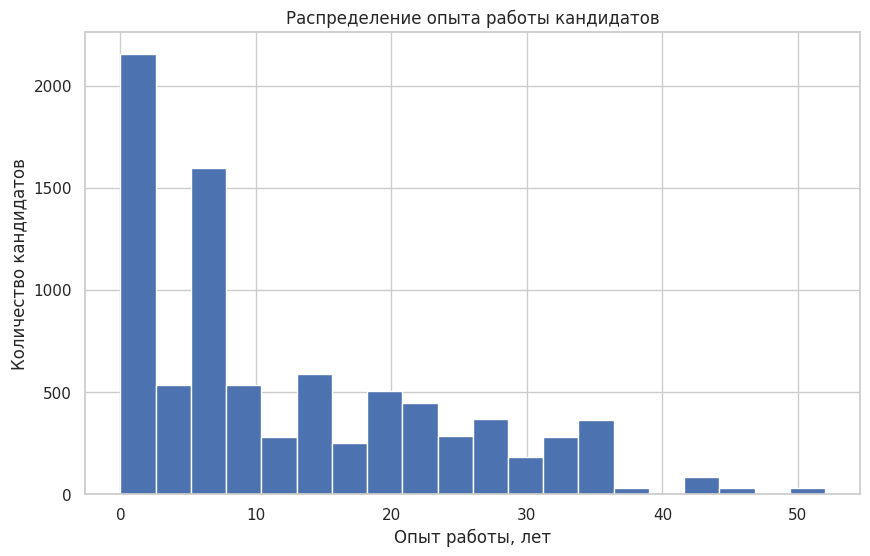

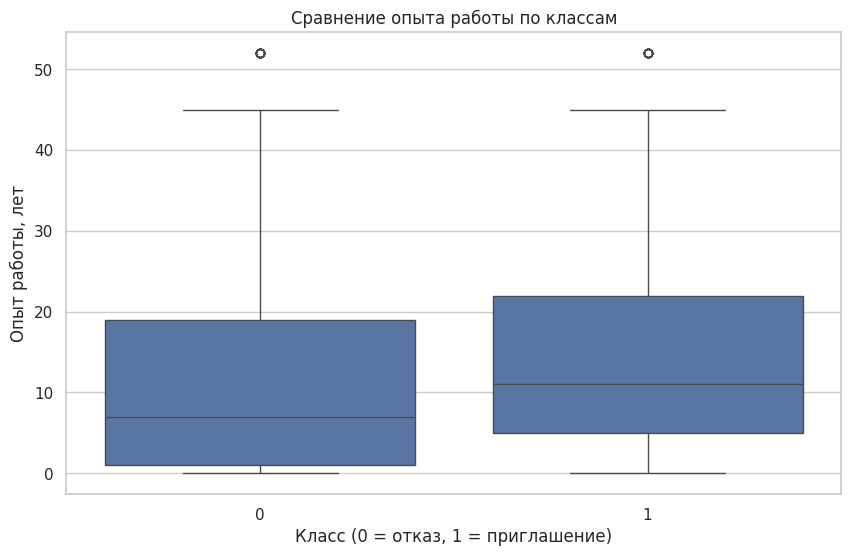

In [9]:
# %%
# ============================
# 8. Анализ опыта работы
# ============================

pct_less5 = (data["experience_years"] < 5).mean() * 100
print(f"Доля кандидатов с опытом менее 5 лет: {pct_less5:.2f}%")

plt.figure()
data["experience_years"].dropna().hist(bins=20)
plt.title("Распределение опыта работы кандидатов")
plt.xlabel("Опыт работы, лет")
plt.ylabel("Количество кандидатов")
plt.show()

# %%
# Сравнение опыта по классам target
plt.figure()
sns.boxplot(data=data, x="target", y="experience_years")
plt.title("Сравнение опыта работы по классам")
plt.xlabel("Класс (0 = отказ, 1 = приглашение)")
plt.ylabel("Опыт работы, лет")
plt.show()

Топ-20 навыков:
python: 3640
machine learning: 3444
sql: 1736
data analysis: 1568
deep learning: 1512
excel: 1494
java: 1204
c++: 1148
natural language processing: 1092
sales: 1068
artificial intelligence: 980
documentation: 952
data science: 924
project management: 924
accounting: 846
tableau: 840
microsoft office: 840
data mining: 812
processes: 812
c: 784


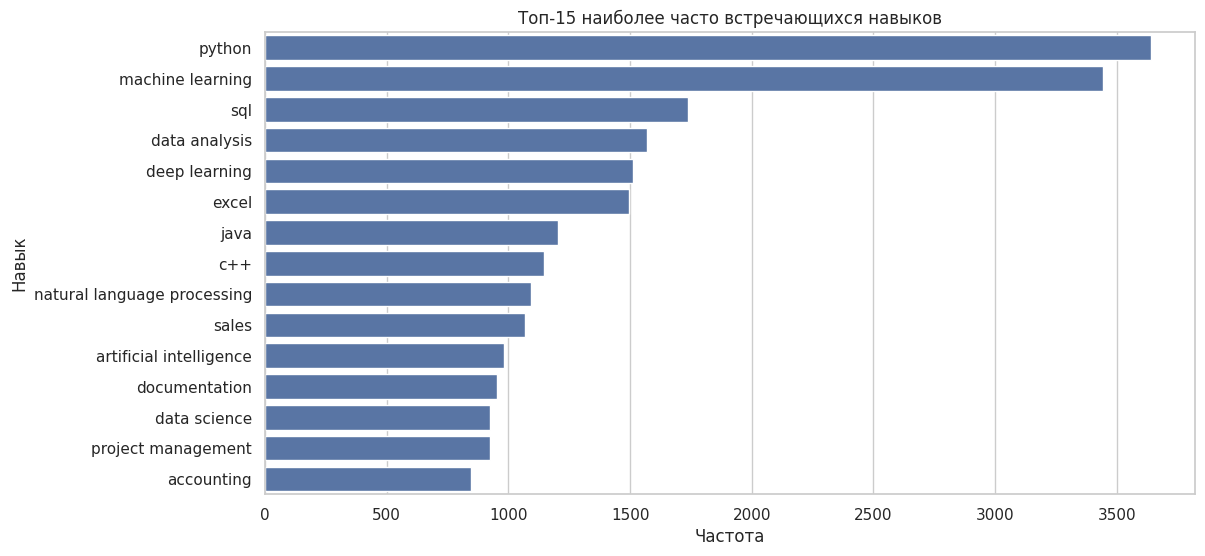

In [10]:
# %%
# ============================
# 9. Частотный анализ навыков
# ============================

all_skills = []

for s in data["skills"].dropna():
    try:
        skills_list = ast.literal_eval(s)
        all_skills.extend(skills_list)
    except Exception:
        continue

skill_counts = Counter([str(skill).strip().lower() for skill in all_skills])

top_20_skills = skill_counts.most_common(20)

print("Топ-20 навыков:")
for skill, count in top_20_skills:
    print(f"{skill}: {count}")

# %%
# Визуализация топ-15 навыков
top_skills_df = pd.DataFrame(top_20_skills, columns=["skill", "count"]).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_skills_df, x="count", y="skill")
plt.title("Топ-15 наиболее часто встречающихся навыков")
plt.xlabel("Частота")
plt.ylabel("Навык")
plt.show()

In [11]:
# ============================
# 10. Создание общего текстового поля
# ============================

data["resume_text"] = (
    data["career_objective"].fillna("").astype(str) + " " +
    data["skills"].fillna("").astype(str)
)

display(data[["career_objective", "skills", "resume_text"]].head())

,career_objective,skills,resume_text
0,Big data analytics working and database wareho...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",Big data analytics working and database wareho...
1,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...",Fresher looking to join as a data analyst and ...
2,None,"['Software Development', 'Machine Learning', '...","['Software Development', 'Machine Learning', ..."
3,To obtain a position in a fast-paced business ...,"['accounts payables', 'accounts receivables', ...",To obtain a position in a fast-paced business ...
4,Professional accountant with an outstanding wo...,"['Analytical reasoning', 'Compliance testing k...",Professional accountant with an outstanding wo...


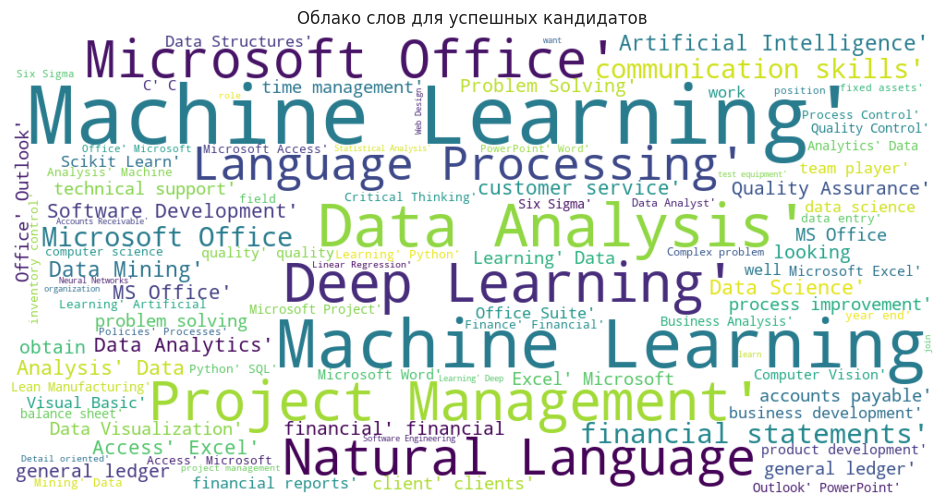

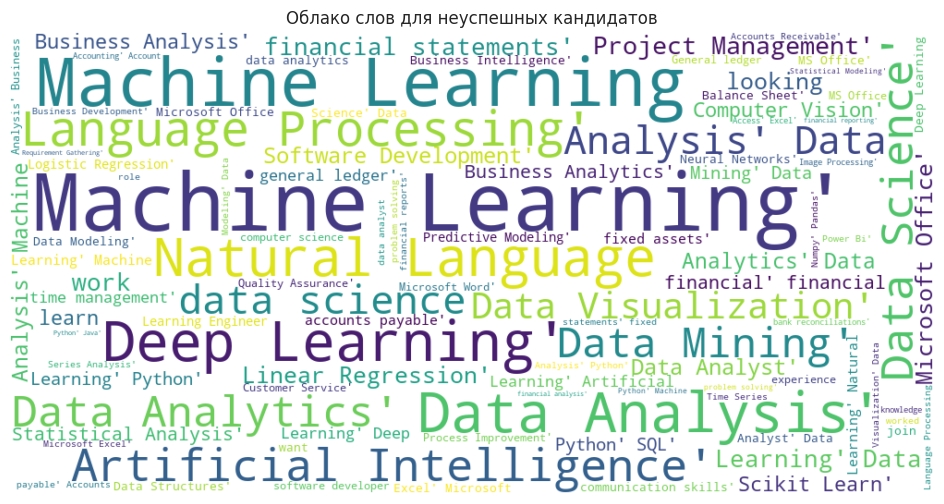

In [12]:
# ============================
# 11. Построение облаков слов
# ============================

success_text = " ".join(data.loc[data["target"] == 1, "resume_text"].astype(str))
fail_text = " ".join(data.loc[data["target"] == 0, "resume_text"].astype(str))

def plot_wordcloud(text, title):
    """
    Строит облако слов по переданному тексту.
    """
    if not text.strip():
        print(f"Недостаточно данных для построения облака слов: {title}")
        return

    wc = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        max_words=100
    ).generate(text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

plot_wordcloud(success_text, "Облако слов для успешных кандидатов")
plot_wordcloud(fail_text, "Облако слов для неуспешных кандидатов")

In [14]:
# ============================
# 12. Функция очистки текста
# ============================

def preprocess_text(text):
    """
    Выполняет базовую предобработку текста:
    - нижний регистр
    - удаление пунктуации
    - удаление стоп-слов
    - лемматизация
    """
    text = str(text).lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words]
    return " ".join(tokens)

data["resume_text_clean"] = data["resume_text"].fillna("").apply(preprocess_text)

display(data[["resume_text", "resume_text_clean"]].head())

,resume_text,resume_text_clean
0,Big data analytics working and database wareho...,big data analytics working database warehouse ...
1,Fresher looking to join as a data analyst and ...,fresher looking join data analyst junior data ...
2,"['Software Development', 'Machine Learning', ...",software development machine learning deep lea...
3,To obtain a position in a fast-paced business ...,obtain position fastpaced business office envi...
4,Professional accountant with an outstanding wo...,professional accountant outstanding work ethic...


In [15]:
# %%
# ============================
# 13. Построение TF-IDF признаков
# ============================

vectorizer = TfidfVectorizer(max_features=500)
X_text = vectorizer.fit_transform(data["resume_text_clean"])

print("Размерность TF-IDF-матрицы:", X_text.shape)

# %%
# Посмотрим на часть словаря
feature_names_text = vectorizer.get_feature_names_out()
print("Пример признаков TF-IDF:")
print(feature_names_text[:30])

Размерность TF-IDF-матрицы: (9544, 500)
Пример признаков TF-IDF:
['2000' 'ability' 'access' 'account' 'accountant' 'accounting' 'accrual'
 'administration' 'administrative' 'adobe' 'advanced' 'agency' 'agile'
 'algorithm' 'also' 'always' 'analysis' 'analyst' 'analytical' 'analytics'
 'android' 'api' 'apple' 'application' 'apply' 'approach' 'ar'
 'architecture' 'area' 'artificial']


Распределение по уровню образования:


education_level
Bachelor    5340
Master      2536
Other       1528
PhD          140
Name: count, dtype: int64

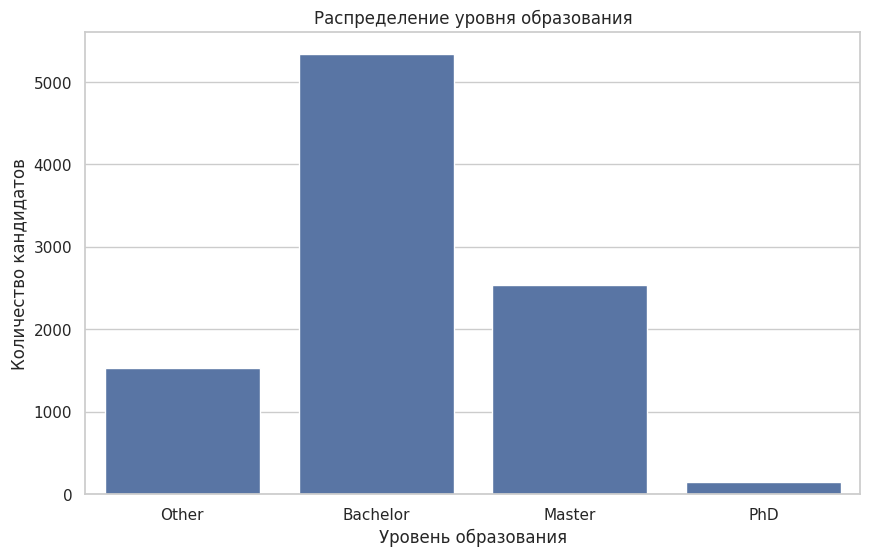

In [16]:
# ============================
# 14. Извлечение уровня образования
# ============================

def get_education_level(degree_list_str):
    """
    Преобразует список степеней в одну категорию образования:
    Other / Bachelor / Master / PhD
    """
    try:
        degrees = ast.literal_eval(degree_list_str) if pd.notna(degree_list_str) else []
    except Exception:
        return "Other"

    level = "Other"

    for degree in degrees:
        degree = str(degree).lower().strip()

        if "phd" in degree or "doctor" in degree:
            return "PhD"

        if (
            degree.startswith("m.")
            or "master" in degree
            or degree.startswith("mba")
            or degree.startswith("mtech")
            or degree.startswith("msc")
        ):
            level = "Master"

        if (
            degree.startswith("b.")
            or degree.startswith("btech")
            or degree.startswith("bsc")
            or "bachelor" in degree
        ):
            if level not in ["Master", "PhD"]:
                level = "Bachelor"

    return level

data["education_level"] = data["degree_names"].fillna("[]").apply(get_education_level)

edu_mapping = {
    "Other": 0,
    "Bachelor": 1,
    "Master": 2,
    "PhD": 3
}

data["education_level_code"] = data["education_level"].map(edu_mapping)

print("Распределение по уровню образования:")
display(data["education_level"].value_counts())

# %%
# Визуализация распределения образования
plt.figure()
sns.countplot(data=data, x="education_level", order=["Other", "Bachelor", "Master", "PhD"])
plt.title("Распределение уровня образования")
plt.xlabel("Уровень образования")
plt.ylabel("Количество кандидатов")
plt.show()

In [17]:
# ============================
# 15. Ключевые слова
# ============================

keywords = ["python", "sql", "excel", "machine learning"]

for kw in keywords:
    col_name = f"has_{kw.replace(' ', '_')}"
    data[col_name] = data["resume_text_clean"].str.contains(kw, regex=False).astype(int)

keyword_cols = [f"has_{kw.replace(' ', '_')}" for kw in keywords]

print("Созданные бинарные признаки:")
print(keyword_cols)

display(data[keyword_cols].head())

Созданные бинарные признаки:
['has_python', 'has_sql', 'has_excel', 'has_machine_learning']


,has_python,has_sql,has_excel,has_machine_learning
0,1,0,0,1
1,0,0,0,1
2,1,0,0,1
3,0,0,1,0
4,0,0,0,0


In [18]:
# ============================
# 16. Объединение текстовых и числовых признаков
# ============================

numeric_feats = data[
    ["experience_years", "education_level_code"] + keyword_cols
].fillna(0)

X = hstack([X_text, numeric_feats.values])
y = data["target"].values

print("Размер итоговой матрицы признаков:", X.shape)
print("Размер целевой переменной:", y.shape)

# %%
# Сохраняем названия признаков для анализа модели
feature_names = (
    list(vectorizer.get_feature_names_out()) +
    ["experience_years", "education_level_code"] +
    keyword_cols
)

print("Общее количество признаков:", len(feature_names))

Размер итоговой матрицы признаков: (9544, 506)
Размер целевой переменной: (9544,)
Общее количество признаков: 506


In [19]:
# ============================
# 17. Train-test split
# ============================

indices = np.arange(len(data))

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X,
    y,
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (7635, 506)
Размер тестовой выборки: (1909, 506)


In [20]:
# ============================
# 18. Обучение Logistic Regression
# ============================

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

print("Модель Logistic Regression успешно обучена.")

# %%
# Анализ коэффициентов логистической регрессии
coef = lr.coef_[0]
feat_coef = list(zip(feature_names, coef))
feat_coef_sorted = sorted(feat_coef, key=lambda x: x[1], reverse=True)

print("Топ-10 признаков с положительным влиянием:")
for feat, c in feat_coef_sorted[:10]:
    print(f"{feat}: {c:.4f}")

print("\nТоп-10 признаков с отрицательным влиянием:")
for feat, c in feat_coef_sorted[-10:]:
    print(f"{feat}: {c:.4f}")

Модель Logistic Regression успешно обучена.
Топ-10 признаков с положительным влиянием:
professional: 2.3481
scheduling: 2.0491
skill: 2.0316
best: 1.9562
performance: 1.8094
database: 1.6436
solidworks: 1.4968
plc: 1.4815
goal: 1.4782
direct: 1.4732

Топ-10 признаков с отрицательным влиянием:
drawing: -1.1372
time: -1.1378
operation: -1.1399
electrical: -1.2383
sale: -1.3250
reconciliation: -1.3340
maintenance: -1.3622
government: -1.3832
science: -1.8192
fresher: -3.1554


In [21]:
# ============================
# 19. Обучение Random Forest
# ============================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)

print("Модель Random Forest успешно обучена.")

Модель Random Forest успешно обучена.


In [22]:
# ============================
# 20. Предсказания моделей
# ============================

y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

In [23]:
# ============================
# 21. Расчёт метрик
# ============================

metrics = {
    "Logistic Regression": {
        "Precision": precision_score(y_test, y_pred_lr, zero_division=0),
        "Recall": recall_score(y_test, y_pred_lr, zero_division=0),
        "F1-score": f1_score(y_test, y_pred_lr, zero_division=0),
    },
    "Random Forest": {
        "Precision": precision_score(y_test, y_pred_rf, zero_division=0),
        "Recall": recall_score(y_test, y_pred_rf, zero_division=0),
        "F1-score": f1_score(y_test, y_pred_rf, zero_division=0),
    }
}

metrics_df = pd.DataFrame(metrics).T
print("Сравнение моделей по метрикам:")
display(metrics_df)

# %%
# Подробный отчёт по Logistic Regression
print("Отчёт по Logistic Regression:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

# %%
# Подробный отчёт по Random Forest
print("Отчёт по Random Forest:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Сравнение моделей по метрикам:


,Precision,Recall,F1-score
Logistic Regression,0.656250,0.516779,0.578223
Random Forest,0.644872,0.562640,0.600956


Отчёт по Logistic Regression:
              precision    recall  f1-score   support

           0       0.64      0.76      0.70      1015
           1       0.66      0.52      0.58       894

    accuracy                           0.65      1909
   macro avg       0.65      0.64      0.64      1909
weighted avg       0.65      0.65      0.64      1909

Отчёт по Random Forest:
              precision    recall  f1-score   support

           0       0.65      0.73      0.69      1015
           1       0.64      0.56      0.60       894

    accuracy                           0.65      1909
   macro avg       0.65      0.64      0.64      1909
weighted avg       0.65      0.65      0.65      1909



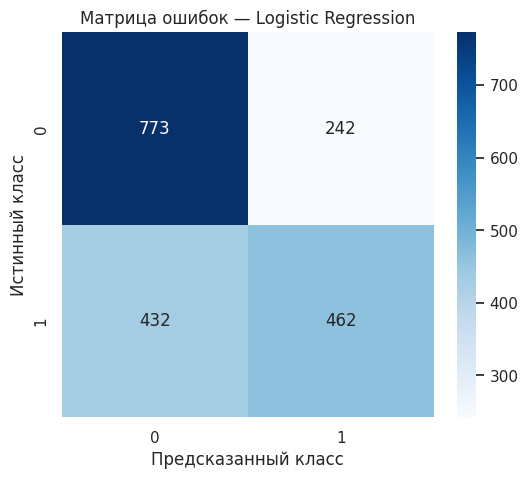

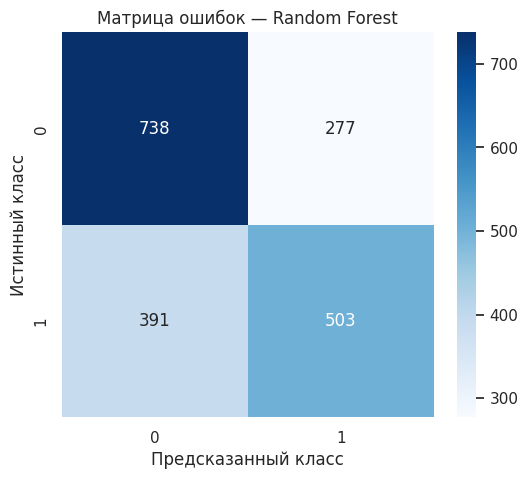

In [24]:
# ============================
# 22. Визуализация матриц ошибок
# ============================

def plot_conf_matrix(y_true, y_pred, title):
    """
    Строит матрицу ошибок.
    """
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Предсказанный класс")
    plt.ylabel("Истинный класс")
    plt.title(title)
    plt.show()

plot_conf_matrix(y_test, y_pred_lr, "Матрица ошибок — Logistic Regression")
plot_conf_matrix(y_test, y_pred_rf, "Матрица ошибок — Random Forest")

Топ-20 наиболее важных признаков Random Forest:
experience_years: 0.0340
machine: 0.0326
learning: 0.0300
skill: 0.0198
has_machine_learning: 0.0193
data: 0.0160
python: 0.0136
microsoft: 0.0126
project: 0.0123
quality: 0.0123
professional: 0.0117
fresher: 0.0113
scheduling: 0.0111
science: 0.0097
office: 0.0095
leadership: 0.0094
management: 0.0094
managing: 0.0090
business: 0.0085
database: 0.0084


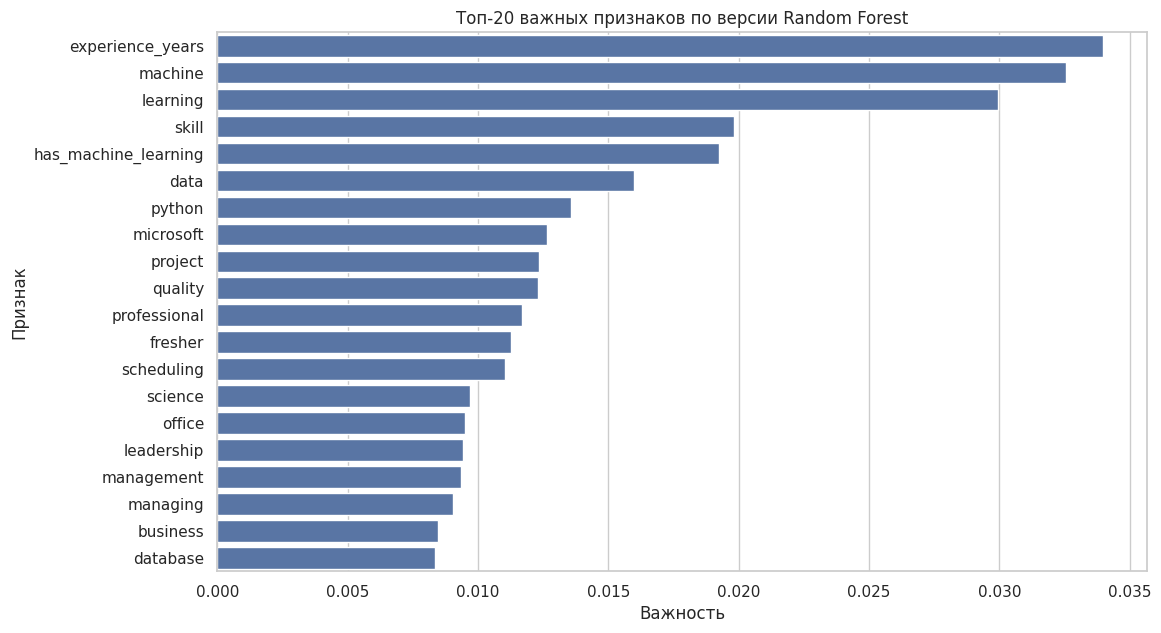

In [25]:
# ============================
# 23. Анализ важности признаков Random Forest
# ============================

importances = rf.feature_importances_
indices_sorted = np.argsort(importances)[-20:][::-1]

top_feats = [(feature_names[i], importances[i]) for i in indices_sorted]

print("Топ-20 наиболее важных признаков Random Forest:")
for feat, imp in top_feats:
    print(f"{feat}: {imp:.4f}")

# %%
# График важности признаков
top_feats_df = pd.DataFrame(top_feats, columns=["feature", "importance"])

plt.figure(figsize=(12, 7))
sns.barplot(data=top_feats_df, x="importance", y="feature")
plt.title("Топ-20 важных признаков по версии Random Forest")
plt.xlabel("Важность")
plt.ylabel("Признак")
plt.show()

In [26]:
# ============================
# 24. Подготовка тестовой таблицы для bias-анализа
# ============================

test_df = data.iloc[idx_test].copy()
test_df["y_true"] = y_test
test_df["y_pred_rf"] = y_pred_rf

display(test_df.head())

,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,resume_text,resume_text_clean,education_level,education_level_code,has_python,has_sql,has_excel,has_machine_learning,y_true,y_pred_rf
2918,None,None,"['Administrative support', 'scheduling appoint...",['Keiser University'],['Bachelor of Sciences'],['N/A'],['N/A'],['N/A'],['Interdisciplinary Studies'],"['Company Name', 'Company Name', 'Company Name...",...,"['Administrative support', 'scheduling appoin...",administrative support scheduling appointment ...,Bachelor,1,0,0,0,0,1,1
9530,None,To pursue excellence in the dynamic business w...,"['3d', 'accounting', 'Accountant', 'Accounts r...","['Vidyasagar University', 'Mohan Lal Sukhadia ...","['MBA', 'N/A']","['2006', '2000']","['N/A', 'N/A']","['N/A', 'N/A']","['Finance', 'N/A']","['Company Name', 'Company Name', 'Auto1 (Al-Gh...",...,To pursue excellence in the dynamic business w...,pursue excellence dynamic business world obtai...,Master,2,0,0,1,0,1,0
8903,"Department of Computer Science, University of ...",None,[],"['University of British Columbia', 'Darmstadt ...","['PhD in Computer Science', 'Hauptdiplom (equi...","['2009', '2004', '2001', '2000']","['N/A', 'Ranking: 1st of 82 students', 'Rankin...","['N/A', 'N/A', 'N/A', 'N/A']","['Computer Science', 'Computer Science', 'Info...","['University of British Columbia', 'University...",...,[],,PhD,3,0,0,0,0,0,1
9148,None,None,"['Program Management', 'Portfolio Management',...","['Claremont Graduate University', 'Claremont G...","['Ph.D.', 'Master of Science', 'Bachelor of Ar...","[None, None, None]","[None, None, None]","[None, None, None]",['Computer Information Systems and Technology'...,"['Company Name', 'Company Name', 'Company Name...",...,"['Program Management', 'Portfolio Management'...",program management portfolio management proces...,Master,2,0,0,1,0,0,1
716,None,Experienced Senior Corporate Accountant dedica...,"['Microsoft Excel expert - Pivot Tables, V-Loo...","['University of North Florida', 'N/A', 'N/A']","['MBA', 'BBA - Accounting', 'BBA - Finance']","['2001', 'N/A', 'N/A']","['N/A', 'CPA qualified candidate', 'CFP qualif...","['N/A', 'N/A', 'N/A']","['Business Administration, Accounting & Financ...","['Company Name', 'Company Name', 'Company Name...",...,Experienced Senior Corporate Accountant dedica...,experienced senior corporate accountant dedica...,Master,2,0,0,1,0,0,1


Recall по группам образования:


/tmp/ipykernel_53/2619588865.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  education_recall = test_df.groupby("education_level").apply(safe_recall)


education_level
Bachelor    0.463675
Master      0.670588
Other       0.631579
PhD         1.000000
dtype: float64

Recall по группам опыта:


/tmp/ipykernel_53/2619588865.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  exp_recall = test_df.groupby("exp_group").apply(safe_recall)
/tmp/ipykernel_53/2619588865.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  exp_recall = test_df.groupby("exp_group").apply(safe_recall)


exp_group
<2 лет      0.382979
2–5 лет     0.684211
5–10 лет    0.551220
>10 лет     0.724311
dtype: float64

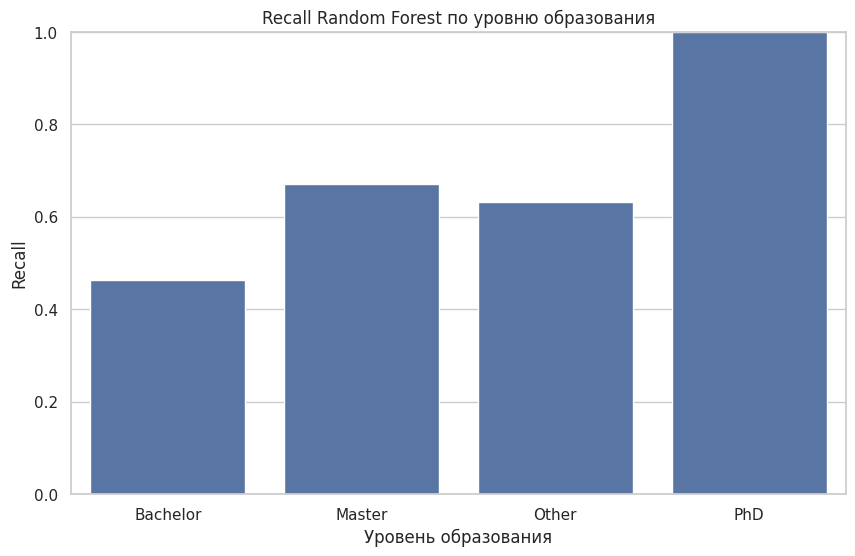

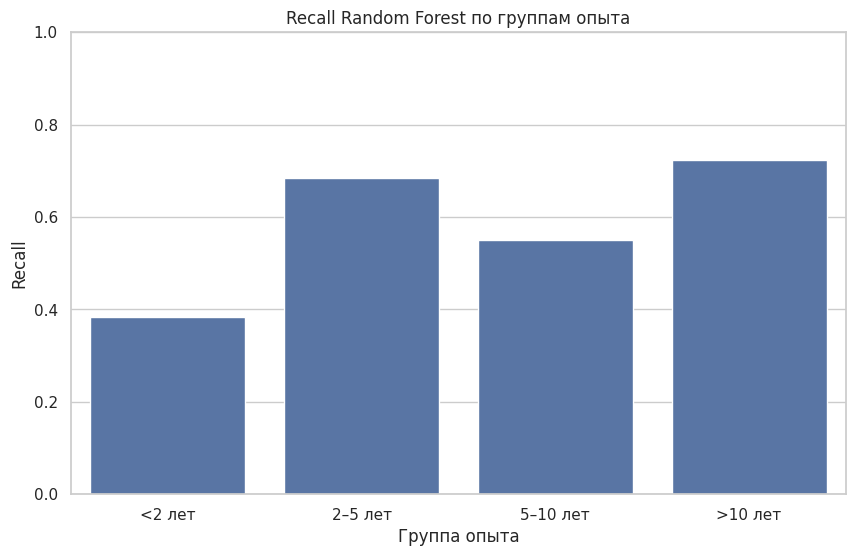

In [27]:
# ============================
# 25. Функция безопасного расчёта recall
# ============================

def safe_recall(group):
    """
    Возвращает recall для группы.
    Если в группе невозможно корректно вычислить метрику,
    возвращает NaN.
    """
    if len(group) == 0:
        return np.nan

    if group["y_true"].sum() == 0:
        return np.nan

    return recall_score(group["y_true"], group["y_pred_rf"], zero_division=0)

# %%
# Recall по уровню образования
education_recall = test_df.groupby("education_level").apply(safe_recall)

print("Recall по группам образования:")
display(education_recall)

# %%
# Формирование групп по опыту
test_df["exp_group"] = pd.cut(
    test_df["experience_years"],
    bins=[0, 2, 5, 10, 50],
    labels=["<2 лет", "2–5 лет", "5–10 лет", ">10 лет"]
)

exp_recall = test_df.groupby("exp_group").apply(safe_recall)

print("Recall по группам опыта:")
display(exp_recall)

# %%
# Визуализация recall по образованию
education_recall_df = education_recall.reset_index()
education_recall_df.columns = ["education_level", "recall"]

plt.figure()
sns.barplot(data=education_recall_df, x="education_level", y="recall")
plt.title("Recall Random Forest по уровню образования")
plt.xlabel("Уровень образования")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.show()

# %%
# Визуализация recall по опыту
exp_recall_df = exp_recall.reset_index()
exp_recall_df.columns = ["exp_group", "recall"]

plt.figure()
sns.barplot(data=exp_recall_df, x="exp_group", y="recall")
plt.title("Recall Random Forest по группам опыта")
plt.xlabel("Группа опыта")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.show()

In [28]:
# ============================
# 26. Сохранение моделей и векторизатора
# ============================

joblib.dump(lr, "models/logistic_model.pkl")
joblib.dump(rf, "models/rf_model.pkl")
joblib.dump(vectorizer, "models/tfidf_vectorizer.pkl")

print("Модели и TF-IDF-векторизатор сохранены в папку models.")

Модели и TF-IDF-векторизатор сохранены в папку models.
